In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\salma\Desktop\dalya\project healthcare\MA supply chain\first milestone\timeseries_version.csv", parse_dates=["Order_Date"])

# Sort by date
df = df.sort_values(by="Order_Date")

# Display first few rows
print(df.head())
print(df.info())  # Check missing values and data types



  Order_Date  Device_Type  Monthly_Demand  Lead_Time  Stock_Level  \
0 2018-01-01     Surgical             565         18          608   
1 2018-01-03  Therapeutic             480         12          497   
2 2018-01-05     Surgical             599          9          646   
3 2018-01-05   Monitoring             478         18          500   
4 2018-01-06   Monitoring             516         12          537   

   Supplier_Reliability  Seasonality_Factor  
0                  0.81            1.007333  
1                  0.91            0.975088  
2                  0.83            1.028933  
3                  0.82            1.044259  
4                  0.72            1.022368  
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_Date            10000 non-null  datetime64[ns]
 1   Device_Type           10000 

<h1> Forecasting with Prophet

In [2]:
# Prepare Data for Prophet

from prophet import Prophet

# Prepare data
prophet_df = df.reset_index()[["Order_Date", "Monthly_Demand"]].rename(columns={"Order_Date": "ds", "Monthly_Demand": "y"}) # Prophet requires 'ds' for date and 'y' for values

# Train-Test Split
train_size = int(len(prophet_df) * 0.8) # Use 80% for training, 20% for testing
train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

23:54:34 - cmdstanpy - INFO - Chain [1] start processing
23:54:39 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\salma\anaconda3\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


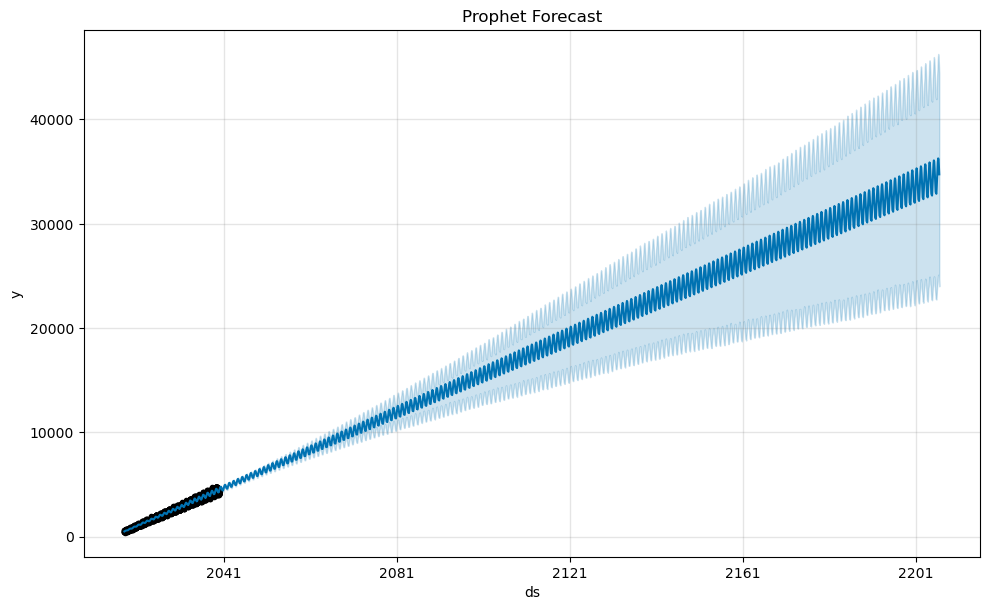

In [3]:
# Train Prophet Model, Prophet auto-detects seasonality and trends

# Initialize and fit model
prophet_model = Prophet(
    seasonality_mode="multiplicative",  # Use multiplicative seasonality helps for percentage-based fluctuations
    yearly_seasonality=True,            # Enable yearly seasonality
    weekly_seasonality=False,           # Disable weekly seasonality (since data is monthly)
    daily_seasonality=False             # Disable daily seasonality
)
prophet_model.fit(train)

# Forecast future demand
future = prophet_model.make_future_dataframe(periods=len(test), freq="M") # Match test set length
forecast = prophet_model.predict(future)

# Plot forecast
fig = prophet_model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

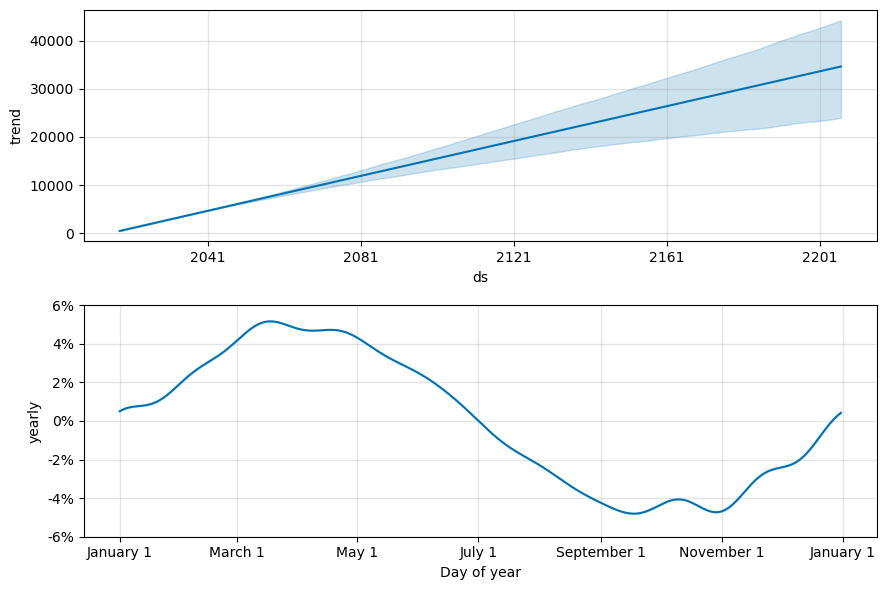

In [4]:
# Plot Components (Trend, Seasonality)
fig2 = prophet_model.plot_components(forecast)
plt.show()

In [6]:
# Evaluate the Model

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# Extract predictions for the test period
results = test[['ds', 'y']].copy()

# Convert 'ds' columns to datetime64[ns] to ensure compatibility
results['ds'] = pd.to_datetime(results['ds'])
forecast['ds'] = pd.to_datetime(forecast['ds'])

# Merge actual values with predictions
results = results.merge(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

# Calculate evaluation metrics
mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
mape = np.mean(np.abs((results['y'] - results['yhat']) / results['y'])) * 100

# Print metrics
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")


MAE: 120.16759516249562
RMSE: 145.1909676145182
MAPE: 2.3864546811784777%


1. MAE (Mean Absolute Error): 120.17

On average, the model's predictions are 120.17 units away from the actual values.
Lower values are better, as they indicate smaller errors.

2. RMSE (Root Mean Squared Error): 145.20

The square root of the average squared difference between the predicted and actual values is 145.20 units.
RMSE penalizes larger errors more heavily than MAE, so it gives a sense of the magnitude of errors.
Lower values are better.

3. MAPE (Mean Absolute Percentage Error): 2.39%

On average, the model's predictions are 2.39% off from the actual values.
MAPE is a relative measure, so it is useful for comparing performance across datasets with different scales.
Lower values are better.

Overall Interpretation:-

MAE and RMSE:

The absolute errors (MAE and RMSE) are relatively high, which suggests that the model's predictions are not very close to the actual values in absolute terms.
However, the interpretation of "high" or "low" depends on the scale of your target variable (Monthly_Demand). So, if your demand values range from 394 to 6053, an MAE of 120.17 might be considered reasonable.

MAPE:

A MAPE of 2.39% is very good. It indicates that, on average, the model's predictions are only 2.39% off from the actual values.
This suggests that the model is performing well in relative terms, even if the absolute errors (MAE and RMSE) seem high.